# Model For Fraud Probability in Consumers


In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV


In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/20 21:38:09 WARN Utils: Your hostname, CompuPau, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/20 21:38:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/20 21:38:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
df_transactions = spark.read.parquet("../data/curated/c_transactions")
df_transactions.show(5)

+-------+--------------+------------+------------------+--------------------+-----------+-----------+--------------------+-----+--------+------+------------------+---------------------+
|user_id|order_datetime|merchant_abn|      dollar_value|            order_id|consumer_id|       name|             address|state|postcode|gender| fraud_probability|is_same_day_duplicate|
+-------+--------------+------------+------------------+--------------------+-----------+-----------+--------------------+-----+--------+------+------------------+---------------------+
|      2|    2021-09-25| 17073441842|2236.4616658010727|74ca0aab-2526-470...|     179208| Mary Smith|     3764 Amber Oval|  NSW|    2782|Female|10.069850934775245|                false|
|     42|    2021-11-20| 91418529927|1849.7149460179146|4bfd1a54-5b19-424...|     412702|James Davis|806 Donaldson Ove...|  NSW|    2158|  Male| 8.927346134856872|                false|
|     67|    2021-09-26| 41663117354|157.49601557824442|9b97971b-c7f1-

In [4]:
df_transactions.count()

14195505

We will try to label the consumers that have a NaN fraud probability.

In [5]:
transactions_all = spark.read.parquet("../data/curated/df_transactions")

# table to keep the order_id
order_lookup = (transactions_all
    .select("order_id", "user_id", "order_datetime")
    .dropDuplicates(["order_id"]))
order_lookup.write.parquet("../data/curated/order_lookup", mode="overwrite")
print(f"order_lookup stored: {order_lookup.count():,} rows")

order_lookup stored: 13,614,675 rows


In [6]:
# take unique values of consumer
consumer_txn_level = df_transactions.select(
    "user_id", "order_datetime", "merchant_abn", "fraud_probability",
    "state", "gender", "postcode", "dollar_value"
).dropDuplicates(["user_id", "order_datetime"])


n_total = consumer_txn_level.count()
n_null = consumer_txn_level.filter(F.col("fraud_probability").isNull()).count()
n_known = n_total - n_null

print(f"Total: {n_total}")
print(f"With fraud_probability: {n_known} ({n_known/n_total:.1%})")
print(f"NULL: {n_null} ({n_null/n_total:.1%})")

pdf_consumer = consumer_txn_level.toPandas()

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Total: 8976957
With fraud_probability: 34765 (0.4%)
NULL: 8942192 (99.6%)


In [7]:
# see fraud probability distribution
labeled_consumer = pdf_consumer[pdf_consumer["fraud_probability"].notna()].copy()

print(labeled_consumer["fraud_probability"].describe(percentiles=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    34765.000000
mean        14.945850
std          9.397401
min          8.287144
5%           8.516635
10%          8.767277
25%          9.630652
50%         11.718317
75%         16.153476
90%         24.156742
95%         33.521229
99%         57.585872
max         99.247380
Name: fraud_probability, dtype: float64


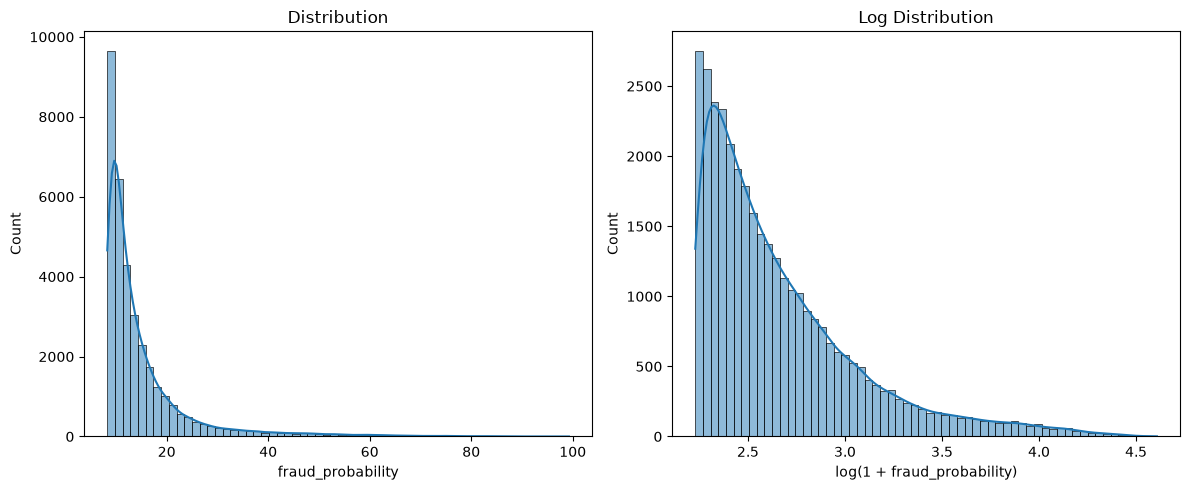

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(labeled_consumer["fraud_probability"], bins=60, kde=True)
plt.title("Distribution")
plt.xlabel("fraud_probability")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(labeled_consumer["fraud_probability"]), bins=60, kde=True)
plt.title("Log Distribution")
plt.xlabel("log(1 + fraud_probability)")

plt.tight_layout()
plt.show()

The distribution is skewed with values mostly concentrated between 9-11.

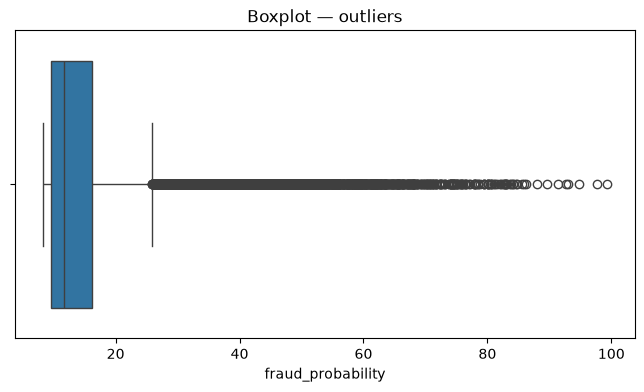

n = 34,765, k = 1.5
Log-scale Q1: 2.3637, Q3: 2.8422, IQR: 0.4785
Log-scale upper bound: 3.5599
Threshold (original): 34.16


In [9]:
# Boxplot 
plt.figure(figsize=(8,4))
sns.boxplot(x=labeled_consumer["fraud_probability"])
plt.title("Boxplot — outliers")
plt.show()

labeled_consumer["log_fraud_probability"] = np.log1p(labeled_consumer["fraud_probability"])

q1 = labeled_consumer["log_fraud_probability"].quantile(0.25)
q3 = labeled_consumer["log_fraud_probability"].quantile(0.75)
iqr = q3 - q1

k = 1.5  
upper_bound_log = q3 + k * iqr
threshold_consumer = np.expm1(upper_bound_log) 
print(f"n = {len(labeled_consumer):,}, k = {k}")
print(f"Log-scale Q1: {q1:.4f}, Q3: {q3:.4f}, IQR: {iqr:.4f}")
print(f"Log-scale upper bound: {upper_bound_log:.4f}")
print(f"Threshold (original): {threshold_consumer:.2f}")

In [10]:
# once having the threshold we apply it for the values that have a fraud probability
pdf_consumer["is_fraud"] = np.where(
    pdf_consumer["fraud_probability"].isna(),
    np.nan,
    (pdf_consumer["fraud_probability"] > threshold_consumer).astype(float)
)

print(pdf_consumer["is_fraud"].value_counts(dropna=False))
print(f"% fraud (labeled only): {pdf_consumer['is_fraud'].mean():.1%}")

is_fraud
NaN    8942192
0.0      33094
1.0       1671
Name: count, dtype: int64
% fraud (labeled only): 4.8%


# Train/test split

In [11]:
# separate the ones that have a label from the ones that don't
seed_set = pdf_consumer[pdf_consumer["is_fraud"].notna()].copy()
unlabeled = pdf_consumer[pdf_consumer["is_fraud"].isna()].copy()  # we're going to try to label these values

print(f"Seed set (with label): {len(seed_set):,}")
print(f"Unlabeled (predict): {len(unlabeled):,}")

# stratified split, using only the labeled transactions
train, test = train_test_split(
    seed_set, test_size=0.3, random_state=42, stratify=seed_set["is_fraud"]
)

print(f"Train set: {len(train):,} samples, {train['is_fraud'].mean():.1%} fraud")
print(f"Test set: {len(test):,} samples, {test['is_fraud'].mean():.1%} fraud")

Seed set (with label): 34,765
Unlabeled (predict): 8,942,192
Train set: 24,335 samples, 4.8% fraud
Test set: 10,430 samples, 4.8% fraud


# Feature Selection
To have a consistent model with the one done with the merchants, we will use Logistics Regression. However, depending on the results, we could test Random Forest as well, since this dataset is bigger.

**Feature Selection**
`dollar_value` is log-transformed, so its scale doesn't dominate the other features.

`state` and `gender` are categorical variables, so we use one-hot-encode.

We exclude `postcode`: like `category` for merchants, it has many distinct values relative to how many labeled rows we have per value, so the model wouldn't be able to generalise from it.

In [12]:
# log-transform dollar_value
pdf_consumer["log_dollar_value"] = np.log1p(pdf_consumer["dollar_value"])


# re-slice seed_set / unlabeled now that the log column exists
seed_set = pdf_consumer[pdf_consumer["is_fraud"].notna()].copy()
unlabeled = pdf_consumer[pdf_consumer["is_fraud"].isna()].copy()

num_cols = ["log_dollar_value"]
cat_cols = ["state", "gender"]
feature_cols = num_cols + cat_cols

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

# pipeline for model
model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

# Validating Model

We repeat the split 30 times with different seeds to see if the prediction AUC holds.

In [13]:
n_repeats = 30
baseline_aucs = []

for seed in range(n_repeats):
    tr, te = train_test_split(seed_set, test_size=0.3, random_state=seed, stratify=seed_set["is_fraud"])
    m = clone(model)
    m.fit(tr[feature_cols], tr["is_fraud"])
    auc = roc_auc_score(te["is_fraud"], m.predict_proba(te[feature_cols])[:, 1])
    baseline_aucs.append(auc)

baseline_aucs = np.array(baseline_aucs)
print(f"Baseline AUC (30 splits): {baseline_aucs.mean():.3f} +/- {baseline_aucs.std():.3f}")

Baseline AUC (30 splits): 0.673 +/- 0.013


To compare results, we will also use Random Forest.

In [14]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )),
])

In [15]:
n_repeats = 30
baseline_aucs = []

for seed in range(n_repeats):
    tr, te = train_test_split(seed_set, test_size=0.3, random_state=seed, stratify=seed_set["is_fraud"])
    m = clone(model)
    m.fit(tr[feature_cols], tr["is_fraud"])
    auc = roc_auc_score(te["is_fraud"], m.predict_proba(te[feature_cols])[:, 1])
    baseline_aucs.append(auc)

baseline_aucs = np.array(baseline_aucs)
print(f"Baseline AUC (30 splits): {baseline_aucs.mean():.3f} +/- {baseline_aucs.std():.3f}")

Baseline AUC (30 splits): 0.890 +/- 0.006


Accuracy:  0.895
Precision: 0.261
Recall:    0.649
F1-score:  0.372
AUC:       0.899

              precision    recall  f1-score   support

   not fraud       0.98      0.91      0.94      9929
       fraud       0.26      0.65      0.37       501

    accuracy                           0.90     10430
   macro avg       0.62      0.78      0.66     10430
weighted avg       0.95      0.90      0.92     10430



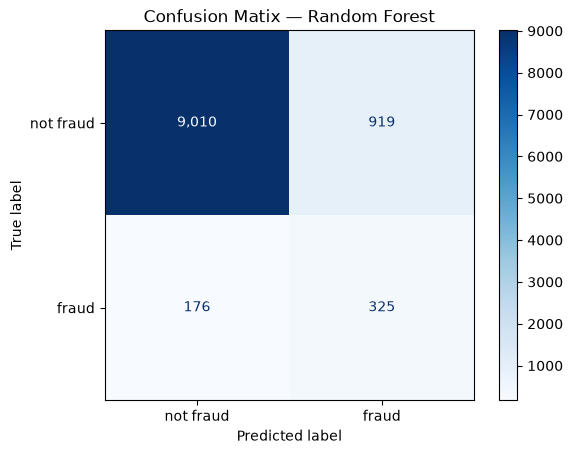

In [16]:
# see results from one model
tr, te = train_test_split(seed_set, test_size=0.3, random_state=42, stratify=seed_set["is_fraud"])

m = clone(model)
m.fit(tr[feature_cols], tr["is_fraud"])

y_true = te["is_fraud"]
y_pred = m.predict(te[feature_cols])
y_proba = m.predict_proba(te[feature_cols])[:, 1]

print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
print(f"Precision: {precision_score(y_true, y_pred):.3f}")
print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_true, y_pred):.3f}")
print(f"AUC:       {roc_auc_score(y_true, y_proba):.3f}")
print()
print(classification_report(y_true, y_pred, target_names=["not fraud", "fraud"]))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["not fraud", "fraud"])
disp.plot(cmap="Blues", values_format=",d")
plt.title("Confusion Matix — Random Forest")
plt.show()

The model performs well when it comes to predicting the no fraud values. When the value is fraud, the model has a low precision, meaning that some cases are flagged as fraud when it shouldn't be the case.

               feature  importance
0     log_dollar_value    0.989404
7            state_VIC    0.001824
9        gender_Female    0.001557
8             state_WA    0.001310
10         gender_Male    0.001233
2            state_NSW    0.001223
5             state_SA    0.000772
3             state_NT    0.000678
4            state_QLD    0.000667
11  gender_Undisclosed    0.000653
6            state_TAS    0.000445
1            state_ACT    0.000234


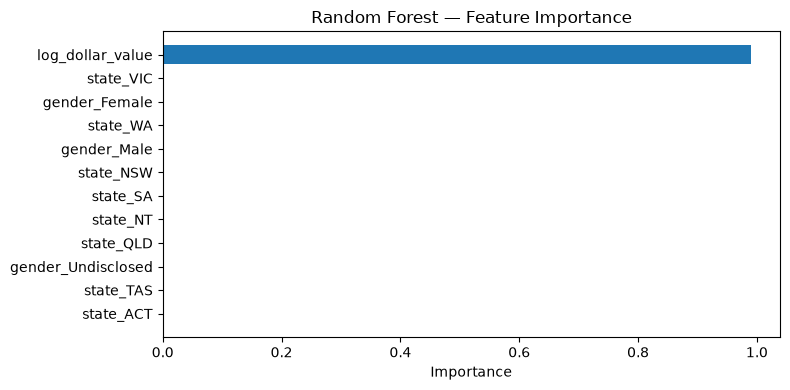

In [17]:
# names of columns after one-hot encoding
ohe = m.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
all_feature_names = num_cols + cat_feature_names

importances = m.named_steps["clf"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

The model is only considering the dollar value to determine if there's a fraud or not, the rest of the features are irrelevant.

In [18]:
# see if the model is actually learning or if it's just learning dollar value
te_check = te.copy()
te_check["proba"] = y_proba
te_check["dollar_value_band"] = pd.qcut(
    te_check["dollar_value"], 5,
    labels=["p0-20", "p20-40", "p40-60", "p60-80", "p80-100"],
    duplicates="drop"
)

print(f"AUC global: {roc_auc_score(te_check['is_fraud'], te_check['proba']):.3f}\n")

for band, group in te_check.groupby("dollar_value_band", observed=True):
    if group["is_fraud"].nunique() < 2:
        print(f"{band}: (n={len(group)}), can't calculate AUC")
        continue
    auc_band = roc_auc_score(group["is_fraud"], group["proba"])
    print(f"{band}: n={len(group):,}, fraud_rate={group['is_fraud'].mean():.1%}, AUC={auc_band:.3f}")

AUC global: 0.899

p0-20: n=2,086, fraud_rate=4.5%, AUC=0.489
p20-40: n=2,086, fraud_rate=4.2%, AUC=0.460
p40-60: n=2,086, fraud_rate=0.5%, AUC=0.846
p60-80: n=2,086, fraud_rate=0.0%, AUC=0.978
p80-100: n=2,086, fraud_rate=14.7%, AUC=0.978


In [19]:
corr_check = seed_set[["fraud_probability", "log_dollar_value"]].corr()
print(corr_check)

                   fraud_probability  log_dollar_value
fraud_probability           1.000000          0.148506
log_dollar_value            0.148506          1.000000


log_dollar_value has a positive correlation with fraud probability of 0.14. Therefore, this suggests that having a higher dollar value, will increase the probability of fraud.

                     mean_dollar_value  fraud_rate     n
dollar_value_decile                                     
0                            13.092151    0.044866  3477
1                            42.843276    0.041427  3476
2                            97.606251    0.045441  3477
3                           289.827120    0.044879  3476
4                          1511.883237    0.010066  3477
5                          2378.993849    0.002014  3476
6                          2885.265119    0.000575  3476
7                          3605.996810    0.000863  3477
8                          4801.568728    0.001438  3476
9                         11435.735471    0.289042  3477


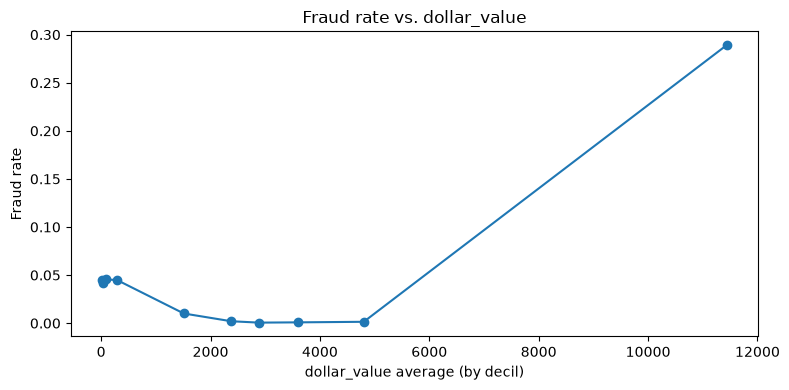

In [20]:
seed_set["dollar_value_decile"] = pd.qcut(seed_set["dollar_value"], 10, labels=False, duplicates="drop")

fraud_by_decile = seed_set.groupby("dollar_value_decile").agg(
    mean_dollar_value=("dollar_value", "mean"),
    fraud_rate=("is_fraud", "mean"),
    n=("is_fraud", "size")
)
print(fraud_by_decile)

plt.figure(figsize=(8, 4))
plt.plot(fraud_by_decile["mean_dollar_value"], fraud_by_decile["fraud_rate"], marker="o")
plt.xlabel("dollar_value average (by decil)")
plt.ylabel("Fraud rate")
plt.title("Fraud rate vs. dollar_value")
plt.tight_layout()
plt.show()

In [21]:
seed_set["dollar_value_pctile"] = pd.qcut(seed_set["dollar_value"], 20, labels=False, duplicates="drop")

fraud_by_pctile = seed_set.groupby("dollar_value_pctile").agg(
    mean_dollar_value=("dollar_value", "mean"),
    median_dollar_value=("dollar_value", "median"),
    fraud_rate=("is_fraud", "mean"),
    n_fraud=("is_fraud", "sum"),
    n=("is_fraud", "size")
)
print(fraud_by_pctile)

# look for outliers
print(seed_set["dollar_value"].describe(percentiles=[0.9, 0.95, 0.99, 0.999]))

                     mean_dollar_value  median_dollar_value  fraud_rate  \
dollar_value_pctile                                                       
0                             6.525562             6.574847    0.044853   
1                            19.662519            19.596788    0.044879   
2                            34.127488            33.820150    0.040852   
3                            51.559063            51.129894    0.042002   
4                            77.498395            76.868529    0.046578   
5                           117.725677           116.414888    0.044304   
6                           191.246784           185.226408    0.043728   
7                           388.407455           373.737488    0.046030   
8                          1070.675398          1014.371703    0.017837   
9                          1952.837363          1971.095216    0.002300   
10                         2259.438171          2261.383150    0.002301   
11                       

The highest dollar_value_pctile has 992 detected values as fraud out of 1739 values. Therefore, this can't be considered as an outlier, instead this are cases were there is a greater probability of having fraud.

In [22]:
max_add_per_round = 200         
pool_sample_size = 200_000       # only take a sample to test the model

results_before, results_after = [], []

for seed in range(n_repeats):
    # train the model
    tr, te = train_test_split(seed_set, test_size=0.3, random_state=seed, stratify=seed_set["is_fraud"])

    m0 = clone(model)
    m0.fit(tr[feature_cols], tr["is_fraud"])

    # predict the values
    pool = unlabeled.sample(n=min(pool_sample_size, len(unlabeled)), random_state=seed).copy()
    pool["pred_proba"] = m0.predict_proba(pool[feature_cols])[:, 1]

    low_threshold = np.percentile(pool["pred_proba"], 10)
    high_threshold = np.percentile(pool["pred_proba"], 90)

    auc_before = roc_auc_score(te["is_fraud"], m0.predict_proba(te[feature_cols])[:, 1])

    # use a threshold of the 10 most confident values
    conf_fraud = pool[pool["pred_proba"] >= high_threshold].nlargest(max_add_per_round, "pred_proba").assign(is_fraud=1.0)
    conf_clean = pool[pool["pred_proba"] <= low_threshold].nsmallest(max_add_per_round, "pred_proba").assign(is_fraud=0.0)
    new_labels = pd.concat([conf_fraud, conf_clean]).drop(columns=["pred_proba"])

    # train model with labels
    tr_aug = pd.concat([tr, new_labels], axis=0)
    m1 = clone(model)
    m1.fit(tr_aug[feature_cols], tr_aug["is_fraud"])
    auc_after = roc_auc_score(te["is_fraud"], m1.predict_proba(te[feature_cols])[:, 1])

    results_before.append(auc_before)
    results_after.append(auc_after)

results_before = np.array(results_before)
results_after = np.array(results_after)

print(f"Before pseudo-labels: {results_before.mean():.3f} +/- {results_before.std():.3f}")
print(f"After  pseudo-labels: {results_after.mean():.3f} +/- {results_after.std():.3f}")
print(f"Splits where it improved: {(results_after > results_before).mean():.1%}")

diff = results_after - results_before

print(f"Mean difference: {diff.mean():.4f}")
print(f"Std of difference: {diff.std():.4f}")
print(f"Splits worsened:  {(diff < 0).mean():.1%}")
print(f"Splits unchanged: {(diff == 0).mean():.1%}")

Before pseudo-labels: 0.890 +/- 0.006
After  pseudo-labels: 0.890 +/- 0.006
Splits where it improved: 36.7%
Mean difference: -0.0004
Std of difference: 0.0012
Splits worsened:  63.3%
Splits unchanged: 0.0%


In this case, we can see that using pseudo-labelling worsens the results rather than improving them. Therefore, we will only use on model without the labelling.

In [23]:
# fit the model
model.fit(seed_set[feature_cols], seed_set["is_fraud"]) 

base_rate = seed_set["is_fraud"].mean()
# predict the unlabeled values
raw_pool_mean = model.predict_proba(unlabeled[feature_cols])[:, 1].mean()
print(f"Real fraud rate in seed set: {base_rate:.1%}")
print(f"Raw (uncalibrated) mean prediction on pool: {raw_pool_mean:.1%}")

Real fraud rate in seed set: 4.8%
Raw (uncalibrated) mean prediction on pool: 43.1%


In [24]:
calibrated_model = CalibratedClassifierCV(model, method="sigmoid", cv=5)
calibrated_model.fit(seed_set[feature_cols], seed_set["is_fraud"])

unlabeled["pred_proba"] = calibrated_model.predict_proba(unlabeled[feature_cols])[:, 1]
print(f"Calibrated mean prediction on pool: {unlabeled['pred_proba'].mean():.1%}")

Calibrated mean prediction on pool: 4.3%


In [25]:
compare = pd.DataFrame({
    "labeled_mean": seed_set[num_cols].mean(),
    "labeled_median": seed_set[num_cols].median(),
    "population_mean": pdf_consumer[num_cols].mean(),
    "population_median": pdf_consumer[num_cols].median(),
})
print(compare)

print()
for col in num_cols:
    pct = (pdf_consumer[col] < seed_set[col].median()).mean()
    print(f"{col}: the labeled median sits at the {pct:.0%} percentile of the full population")

                  labeled_mean  labeled_median  population_mean  \
log_dollar_value      6.519997        7.664876         4.153973   

                  population_median  
log_dollar_value           4.146813  

log_dollar_value: the labeled median sits at the 99% percentile of the full population


In [26]:
# see the reliability of results
for q in [0.10, 0.20, 0.30, 0.40]:
    cutoff = seed_set["log_dollar_value"].quantile(q)
    raw_cutoff = np.expm1(cutoff)  # see cutoffs in dollars
    coverage = (unlabeled["log_dollar_value"] >= cutoff).mean()
    print(f"p{int(q*100)}: log_cutoff={cutoff:.2f}, dollar_cutoff=${raw_cutoff:,.0f}, sample coverage={coverage:.1%}")

p10: log_cutoff=3.32, dollar_cutoff=$27, sample coverage=74.4%
p20: log_cutoff=4.16, dollar_cutoff=$63, sample coverage=49.6%
p30: log_cutoff=4.98, dollar_cutoff=$145, sample coverage=25.8%
p40: log_cutoff=6.35, dollar_cutoff=$571, sample coverage=5.0%


In [27]:
# experiment: train a model where we only consider the relible results
# meaning that prices are higher than 571 (AUC 0.846-0.978)
seed_high = seed_set[seed_set["dollar_value"] >= 571].copy()

tr_high, te_high = train_test_split(
    seed_high, test_size=0.3, random_state=42, stratify=seed_high["is_fraud"]
)

# model
model_proba_high = calibrated_model.predict_proba(te_high[feature_cols])[:, 1]
auc_model_high = roc_auc_score(te_high["is_fraud"], model_proba_high)


auc_naive_high = roc_auc_score(te_high["is_fraud"], te_high["dollar_value"])

print(f"AUC calibrated (tier high): {auc_model_high:.3f}")
print(f"AUC dollar_value (tier high): {auc_naive_high:.3f}")

AUC calibrated (tier high): 0.989
AUC dollar_value (tier high): 0.950


In [28]:
# instead of a single well_supported cutoff, tag each row with a confidence tier

high_cutoff = np.expm1(seed_set["log_dollar_value"].quantile(0.40)) 

def confidence_tier(dollar_value):
    if dollar_value >= high_cutoff:      # p40 boundary, we get an AUC of 0.989
        return "high"
    else:                        # below $571 — AUC 0.46-0.49, no real signal
        return "unreliable"

unlabeled["confidence_tier"] = unlabeled["dollar_value"].apply(confidence_tier)
print(unlabeled["confidence_tier"].value_counts())

# predict for rows where the model actually has signal
well_supported = unlabeled["confidence_tier"] == "high"
unlabeled_final = unlabeled[well_supported].copy()

confidence_tier
unreliable    8491085
high           451107
Name: count, dtype: int64


In [29]:
# used the unlabeled final and join with the whole dataset.
pdf_consumer = pdf_consumer.merge(
    unlabeled_final[["user_id", "order_datetime", "pred_proba"]],
    on=["user_id", "order_datetime"], how="left"
)

pdf_consumer["consumer_fraud_score_final"] = np.where(
    pdf_consumer["fraud_probability"].notna(),
    pdf_consumer["fraud_probability"] / 100,   # normalise
    pdf_consumer["pred_proba"]                 # use prediction of the model
)

n_final_known = pdf_consumer["consumer_fraud_score_final"].notna().sum()
print(f"Rows with a fraud score (real + pseudo-label): {n_final_known:,} / {len(pdf_consumer):,}")
print(f"NULL: {pdf_consumer['consumer_fraud_score_final'].isna().sum():,}")

pdf_consumer["consumer_fraud_score_final"].describe()

Rows with a fraud score (real + pseudo-label): 485,872 / 8,976,957
NULL: 8,491,085


count    485872.000000
mean          0.027737
std           0.060601
min           0.002040
25%           0.004083
50%           0.012391
75%           0.028219
max           0.992474
Name: consumer_fraud_score_final, dtype: float64

In [30]:
threshold_consumer_normalized = threshold_consumer / 100 

# create the is_fraud_consumer variable
pdf_consumer["is_fraud_consumer"] = np.where(
    pdf_consumer["consumer_fraud_score_final"].isna(),
    np.nan,
    (pdf_consumer["consumer_fraud_score_final"] > threshold_consumer_normalized).astype(float)
)

print(pdf_consumer["is_fraud_consumer"].value_counts(dropna=False))

is_fraud_consumer
NaN    8491085
0.0     482098
1.0       3774
Name: count, dtype: int64


In [31]:
pdf_consumer = pdf_consumer[[
    "user_id", "order_datetime", "consumer_fraud_score_final", "is_fraud_consumer"
]].copy()

pdf_consumer.to_parquet("../data/curated/consumer_fraud_labels.parquet", index=False)
print(f"Stored: {len(pdf_consumer):,} rows")

Stored: 8,976,957 rows


In [32]:
# order lookup
order_lookup = spark.read.parquet("../data/curated/order_lookup").toPandas()

# merge to have order_id in the table
pdf_consumer_by_order = order_lookup.merge(
    pdf_consumer[["user_id", "order_datetime", "consumer_fraud_score_final", "is_fraud_consumer"]],
    on=["user_id", "order_datetime"], how="left"
)

print(f"Rows: {len(pdf_consumer_by_order):,} (before: {len(pdf_consumer):,})")

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Rows: 13,614,675 (before: 8,976,957)


In [33]:
pdf_consumer_by_order[["order_id", "consumer_fraud_score_final", "is_fraud_consumer"]].to_parquet(
    "../data/curated/consumer_fraud_labels.parquet", index=False
)

# Important considerations
The trained model was only able to identify fraud cases when the dollar value was high; the performance of the model was unreliable. For this reason, we will still have 8491085 NaN values in the dataset, since it was not possible to determine with accuracy whether or not these consumers committed fraud during the transaction.